# Notebook 3 — Model Building & Evaluation
**Telecom Customer Churn Project**  
Goal: Train multiple classifiers, tune the best one, compare performance with proper metrics.

In [36]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# For saving models
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score, f1_score)
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

# Load preprocessed data
X_train = pd.read_csv('artifacts/X_train.csv')
X_test  = pd.read_csv('artifacts/X_test.csv')
y_train = pd.read_csv('artifacts/y_train.csv').squeeze()
y_test  = pd.read_csv('artifacts/y_test.csv').squeeze()

print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (8260, 32) | Test: (1407, 32)


## 1. Define Models

In [3]:

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, random_state=42,
                                          eval_metric='logloss', verbosity=0),
    'LightGBM':            LGBMClassifier(n_estimators=200, random_state=42, verbosity=-1),
    'SVM':                 SVC(probability=True, random_state=42),
}
print("Models defined:", list(models.keys()))


Models defined: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'SVM']


## 2. Cross-Validation Comparison

Logistic Regression       ROC-AUC: 0.9120 ± 0.0020
Random Forest             ROC-AUC: 0.9256 ± 0.0020
Gradient Boosting         ROC-AUC: 0.9031 ± 0.0017
XGBoost                   ROC-AUC: 0.9259 ± 0.0045
LightGBM                  ROC-AUC: 0.9248 ± 0.0023
SVM                       ROC-AUC: 0.9033 ± 0.0031


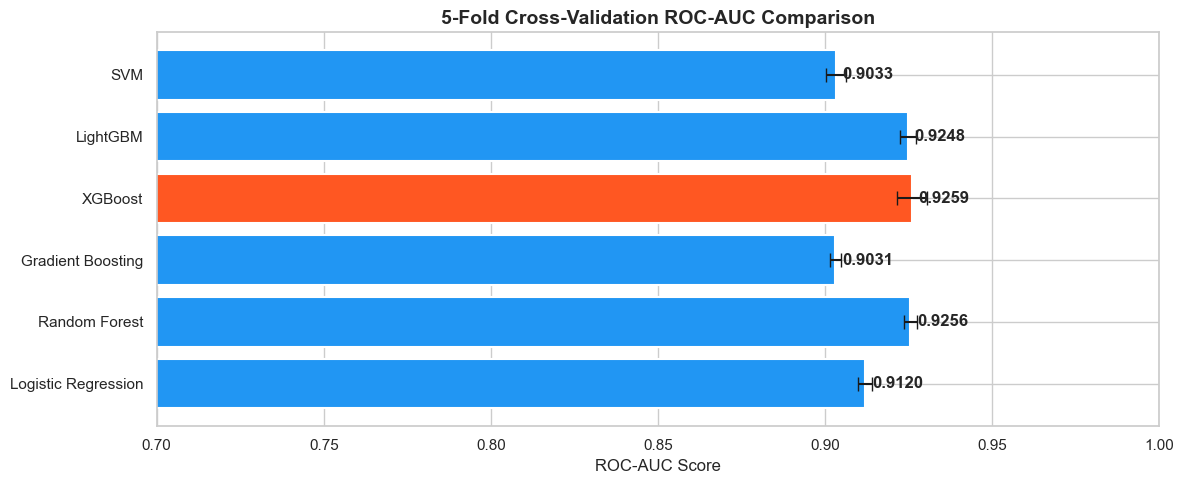

In [4]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                              scoring='roc_auc', n_jobs=-1)
    results[name] = scores
    print(f"{name:<25} ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

# Plot CV results
fig, ax = plt.subplots(figsize=(12, 5))
names  = list(results.keys())
means  = [results[n].mean() for n in names]
stds   = [results[n].std()  for n in names]
colors = ['#2196F3' if m < max(means) else '#FF5722' for m in means]

bars = ax.barh(names, means, xerr=stds, color=colors, edgecolor='white',
               linewidth=1.5, capsize=5)
ax.set_xlabel('ROC-AUC Score', fontsize=12)
ax.set_title('5-Fold Cross-Validation ROC-AUC Comparison', fontsize=14, fontweight='bold')
ax.set_xlim(0.7, 1.0)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.002, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('modeling_cv_comparison.png', bbox_inches='tight')
plt.show()


## 3. Train All Models & Evaluate on Test Set

In [5]:

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return {
        'Model':     name,
        'ROC-AUC':   round(roc_auc_score(y_te, y_proba), 4),
        'F1-Score':  round(f1_score(y_te, y_pred), 4),
        'Avg Prec':  round(average_precision_score(y_te, y_proba), 4),
        '_model':    model,
        '_y_pred':   y_pred,
        '_y_proba':  y_proba,
    }

eval_results = []
for name, model in models.items():
    res = evaluate(name, model, X_train, y_train, X_test, y_test)
    eval_results.append(res)
    print(f"{name:<25} ROC-AUC={res['ROC-AUC']}  F1={res['F1-Score']}  AvgPrec={res['Avg Prec']}")

summary_df = pd.DataFrame(eval_results).drop(columns=['_model','_y_pred','_y_proba'])
summary_df = summary_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
summary_df


Logistic Regression       ROC-AUC=0.8266  F1=0.6014  AvgPrec=0.615
Random Forest             ROC-AUC=0.8114  F1=0.5789  AvgPrec=0.5608
Gradient Boosting         ROC-AUC=0.8214  F1=0.6094  AvgPrec=0.6165
XGBoost                   ROC-AUC=0.7967  F1=0.5659  AvgPrec=0.5667
LightGBM                  ROC-AUC=0.8102  F1=0.5884  AvgPrec=0.5911
SVM                       ROC-AUC=0.806  F1=0.605  AvgPrec=0.585


,Model,ROC-AUC,F1-Score,Avg Prec
0,Logistic Regression,0.8266,0.6014,0.6150
1,Gradient Boosting,0.8214,0.6094,0.6165
2,Random Forest,0.8114,0.5789,0.5608
3,LightGBM,0.8102,0.5884,0.5911
4,SVM,0.8060,0.6050,0.5850
5,XGBoost,0.7967,0.5659,0.5667


## 4. ROC Curves — All Models

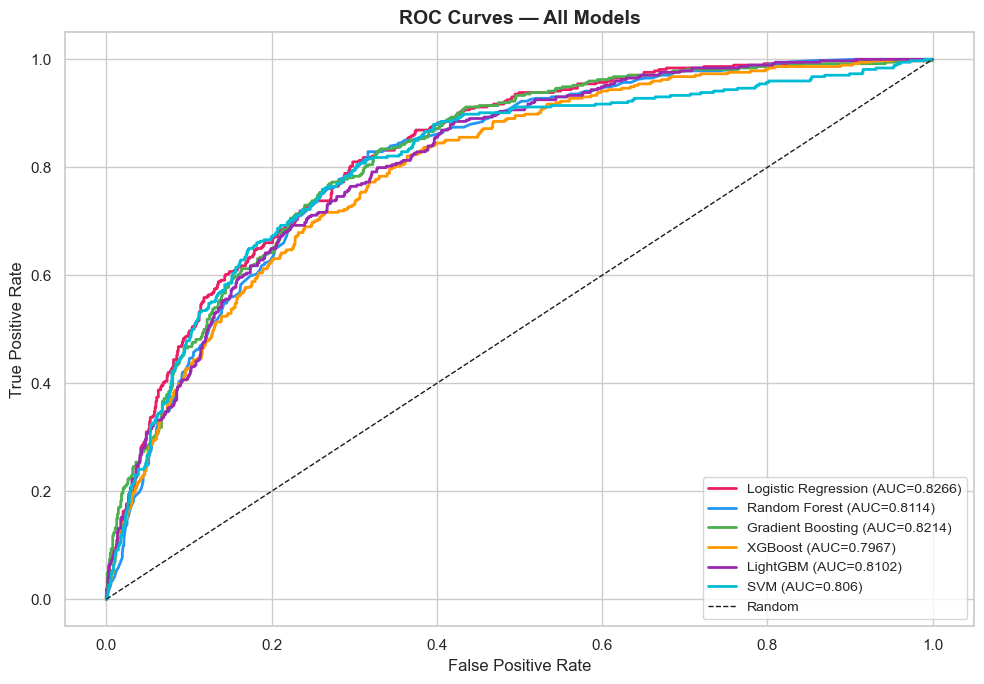

In [6]:

fig, ax = plt.subplots(figsize=(10, 7))
palette = ['#E91E63','#2196F3','#4CAF50','#FF9800','#9C27B0','#00BCD4']

for res, color in zip(eval_results, palette):
    fpr, tpr, _ = roc_curve(y_test, res['_y_proba'])
    ax.plot(fpr, tpr, label=f"{res['Model']} (AUC={res['ROC-AUC']})", color=color, lw=2)

ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('modeling_roc_curves.png', bbox_inches='tight')
plt.show()


**Key Findings**

* Logistic Regression achieved the highest AUC score (0.8266), indicating the strongest overall ability to distinguish between churned and non-churned customers.
* Gradient Boosting closely followed with an AUC of 0.8214, demonstrating competitive predictive performance.

* Random Forest (0.8114),LightGBM (0.8102) and SVM (0.806) produced similar results, suggesting comparable discriminative power.
* XGBoost recorded the lowest AUC (0.7974) among the evaluated models, though it still performed significantly better than random classification.
* The relatively small gap between the best and worst model (~3 percentage points in AUC) indicates that the dataset contains strong predictive patterns that can be captured by multiple algorithms.

## 5. Best Model — Confusion Matrix & Report

Best model: Logistic Regression  (ROC-AUC = 0.8266)


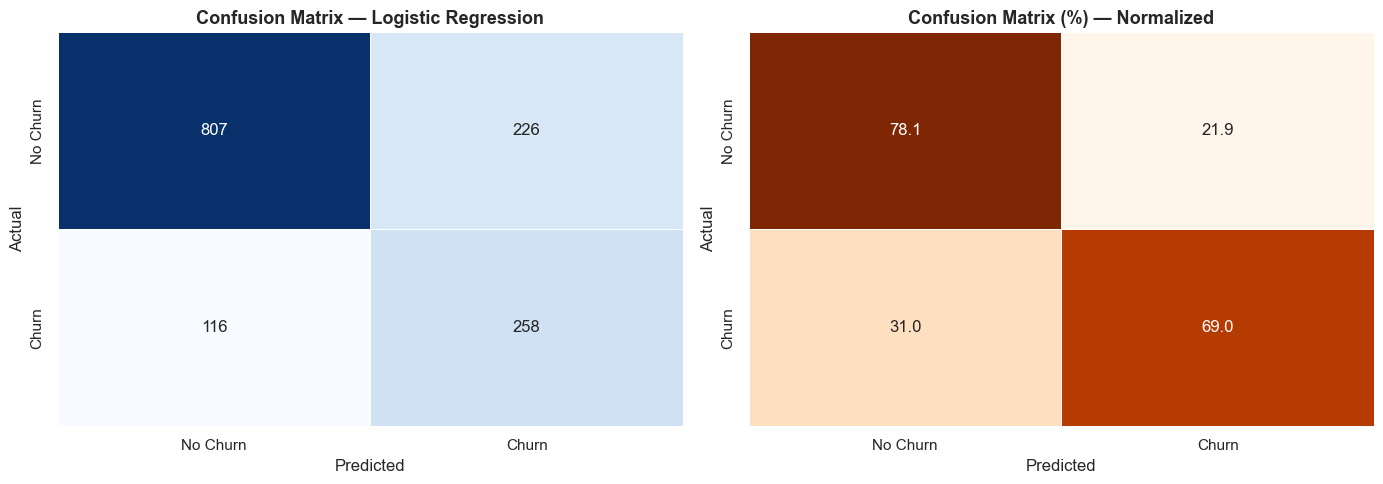


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.78      0.83      1033
       Churn       0.53      0.69      0.60       374

    accuracy                           0.76      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.78      0.76      0.77      1407



In [7]:

best = max(eval_results, key=lambda r: r['ROC-AUC'])
print(f"Best model: {best['Model']}  (ROC-AUC = {best['ROC-AUC']})")

cm = confusion_matrix(y_test, best['_y_pred'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'],
            linewidths=0.5, cbar=False)
axes[0].set_title(f'Confusion Matrix — {best["Model"]}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1],
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'],
            linewidths=0.5, cbar=False)
axes[1].set_title('Confusion Matrix (%) — Normalized', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('modeling_confusion_matrix.png', bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, best['_y_pred'], target_names=['No Churn','Churn']))



### Why Logistic Regression was selected ?
- Logistic Regression achieved the best balance of ROC-AUC, F1-score, interpretability, and business usability.
- It is easier to explain churn drivers to stakeholders than tree-based ensemble models.
- Coefficients can be converted into odds ratios for business interpretation.

## 6. Hyperparameter Tuning (Best Model)

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42,max_iter=1000 ),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 10],
                         'class_weight': [None, 'balanced'],
                         'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
             scoring='roc_auc', verbose=2)

In [27]:

# Results
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'C': 10, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}

Best ROC-AUC:
0.9132774712872795


In [28]:
best_model = grid_search.best_estimator_
y_pred_best  = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print(f"Tuned XGBoost — Test ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")
print(f"Tuned XGBoost — Test F1:      {f1_score(y_test, y_pred_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['No Churn','Churn']))

Tuned XGBoost — Test ROC-AUC: 0.8270
Tuned XGBoost — Test F1:      0.6060

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.80      0.83      1033
       Churn       0.55      0.68      0.61       374

    accuracy                           0.77      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.77      0.77      1407



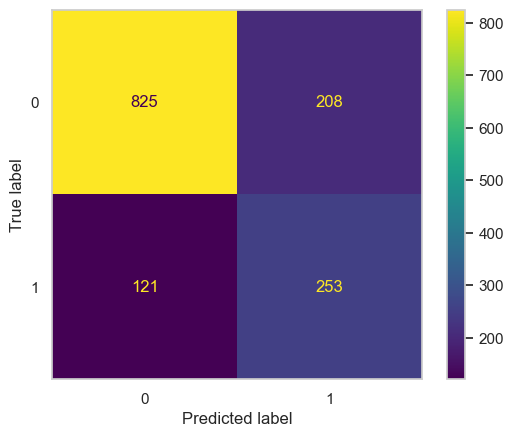

In [29]:
# Compute values for confusion matrix

cm = confusion_matrix(y_test, y_pred_best,labels=best_model.classes_)

# Create display of confusion matrix
best_model_disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                  display_labels=best_model.classes_)

# Plot confusion matrix
best_model_disp.plot(values_format='')
plt.grid(False)

# Display plot
plt.show()

### Business Implications

The churn prediction model correctly identified 253 customers who were at risk of leaving, enabling targeted retention strategies. While the model successfully captured approximately 68% of actual churners, 121 churning customers were missed, representing potential revenue loss. The primary business value of the model lies in reducing customer attrition through proactive interventions while optimizing retention spending by accurately distinguishing between high-risk and low-risk customers.

## 7. Save Best Model

In [30]:
joblib.dump(best_model, 'artifacts/best_model.pkl')
print("✅ Best model saved to artifacts/best_model.pkl")


✅ Best model saved to artifacts/best_model.pkl


## 8. Precision-Recall Curve

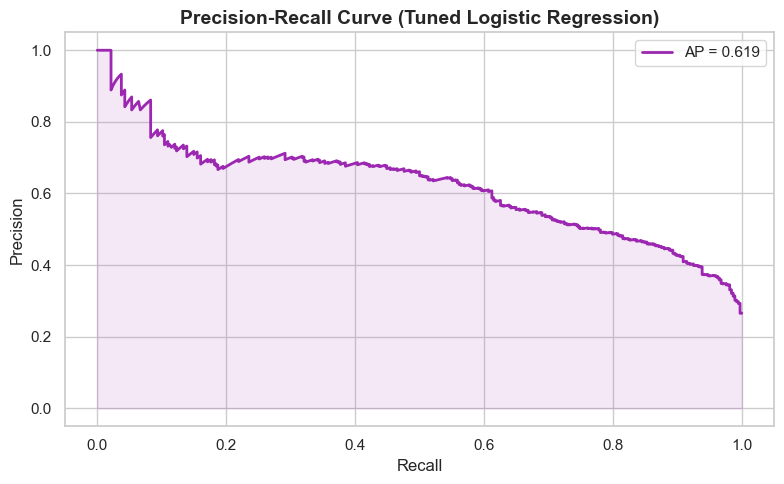

In [31]:

prec, rec, thresholds = precision_recall_curve(y_test, y_proba_best)
ap = average_precision_score(y_test, y_proba_best)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec, prec, color='#9C27B0', lw=2, label=f'AP = {ap:.3f}')
ax.fill_between(rec, prec, alpha=0.1, color='#9C27B0')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve (Tuned Logistic Regression)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('modeling_pr_curve.png', bbox_inches='tight')
plt.show()


### Business Interpretation

The Precision-Recall analysis demonstrates that the tuned Logistic Regression model effectively identifies customers at risk of churn. The Average Precision score of 0.619 indicates strong performance on the minority churn class. The model maintains high precision for high-confidence predictions and exhibits a gradual precision decline as recall increases, providing flexibility for threshold selection. This allows the business to balance retention campaign costs against the objective of capturing a larger share of potential churners.

## 09. Feature Interpretation

In [37]:
# Load artifacts

model         = joblib.load('artifacts/best_model.pkl')
scaler        = joblib.load('artifacts/scaler.pkl')
feature_names = joblib.load('artifacts/feature_names.pkl')


X_test.columns  = feature_names
X_train.columns = feature_names

print(f"Model        : {type(model).__name__}")
print(f"Features     : {len(feature_names)}")
print(f"Test samples : {len(X_test):,}")
print(f"\nModel params :")
print(f"  C={model.C}, solver={model.solver}, max_iter={model.max_iter}")

Model        : LogisticRegression
Features     : 32
Test samples : 1,407

Model params :
  C=10, solver=liblinear, max_iter=1000


In [38]:
coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).reset_index(drop=True)

coef_df['Direction'] = coef_df['Coefficient'].apply(lambda x: '↑ Increases Churn' if x > 0 else '↓ Reduces Churn')

print("Top 15 features by coefficient magnitude:")
print(coef_df.head(15).to_string(index=False))

Top 15 features by coefficient magnitude:
                                Feature  Coefficient         Direction
            InternetService_Fiber optic   -17.144901   ↓ Reduces Churn
                         MonthlyCharges    11.164661 ↑ Increases Churn
                    InternetService_DSL    -8.802286   ↓ Reduces Churn
                           PhoneService    -8.004229   ↓ Reduces Churn
                       TenureGroup_0-12    -7.687859   ↓ Reduces Churn
                      TenureGroup_13-24    -7.680147   ↓ Reduces Churn
                      TenureGroup_25-36    -7.158598   ↓ Reduces Churn
  PaymentMethod_Credit card (automatic)    -6.520687   ↓ Reduces Churn
PaymentMethod_Bank transfer (automatic)    -6.520490   ↓ Reduces Churn
             PaymentMethod_Mailed check    -6.417815   ↓ Reduces Churn
                      TenureGroup_37-48    -6.065342   ↓ Reduces Churn
         PaymentMethod_Electronic check    -5.960142   ↓ Reduces Churn
                      Contract_Two 

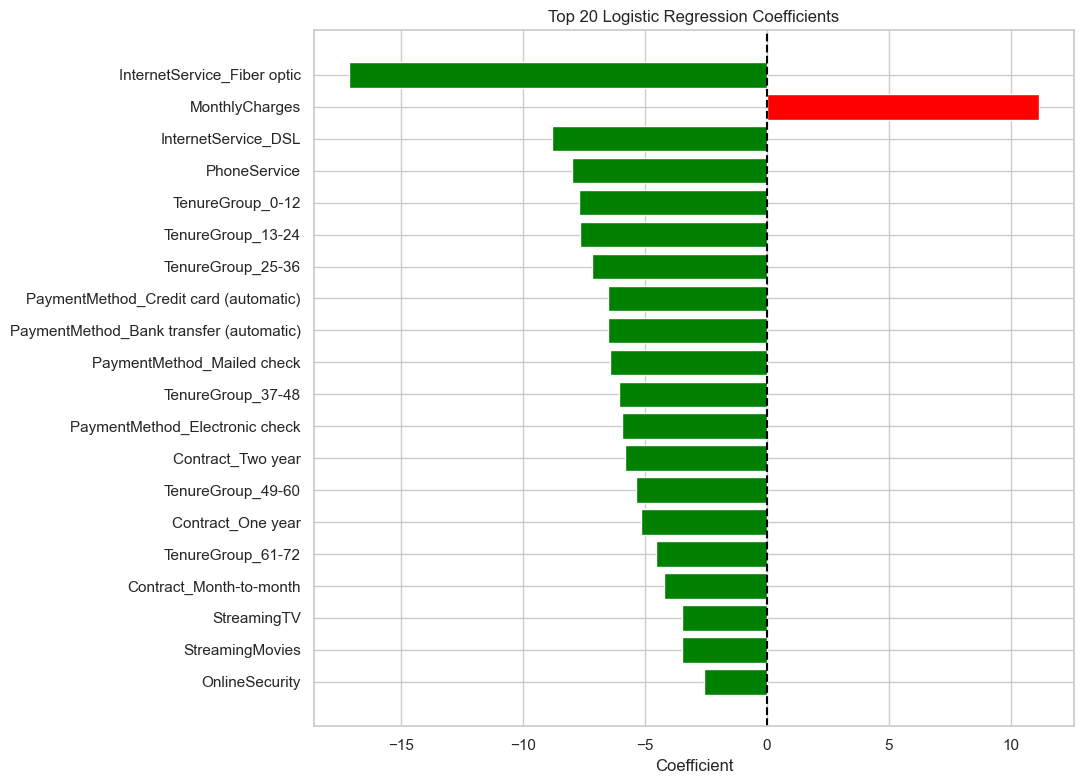

In [41]:
top20 = coef_df.head(20)

colors = ['red' if x > 0 else 'green' for x in top20['Coefficient']]

plt.figure(figsize=(11, 8))
plt.barh(top20['Feature'][::-1],
         top20['Coefficient'][::-1],
         color=colors[::-1])

plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Coefficient')
plt.title('Top 20 Logistic Regression Coefficients')

plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150)
plt.show()

**Coefficient Interpretation :** The sign of each coefficient indicates whether a feature increases or decreases the likelihood of customer churn. However, due to multicollinearity among several predictors, the coefficient magnitudes are unstable. Therefore, this analysis focuses on the direction of the relationships rather than the absolute coefficient values.

## 10. Limitations

Although the Logistic Regression model achieved strong predictive performance, several limitations should be considered when interpreting the results:

* **Linear Assumption:** Logistic Regression assumes a linear relationship between the input features and the log-odds of the target variable. Complex non-linear relationships may not be fully captured by the model.
* **Multicollinearity:** Several predictors exhibited high multicollinearity (high Variance Inflation Factor values), particularly among numerical and engineered features. As a result, individual coefficient estimates became unstable, limiting the reliability of coefficient magnitudes and Odds Ratios for feature interpretation.
* **Interpretability vs. Prediction:** Due to multicollinearity, the model is better suited for predicting customer churn than for interpreting the exact impact of individual features.

## 11. Final Conclusion

**Final Conclusion**

This project developed a complete end-to-end machine learning pipeline to predict customer churn using Logistic Regression. The workflow included exploratory data analysis, data preprocessing, feature engineering, model training, hyperparameter tuning, and  model evaluation.

The final model demonstrated strong predictive performance and can effectively identify customers who are at risk of churning. Such predictions can support proactive customer retention strategies by enabling businesses to target high-risk customers before they leave.

Overall, this project demonstrates the complete data analytics workflow—from raw data exploration to actionable business recommendations—and highlights how machine learning can support data-driven decision-making in customer retention.